In [7]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMinMax


%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 16, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Учимся загружать датасет и обрабатываем его

Для удобства возьмем датасет, который уже разбит на классы и посмотрим, как хорошо его разобьет наша модель

In [8]:
def load_series_only(file_path):
    series_list = []
    classes = []
    with open(file_path, 'r') as f:
        for line in f:
            if not line.strip() or line.startswith('#'):
                continue
            parts = line.split()
            # First element - class_mark
            classes.append(float(parts[0])-1)
            values = [float(p) for p in parts[1:] if p.lower() != 'nan']
            if values:
                series_list.append(values)
    return series_list, classes

file_path = "/home/artemiistradin/Documents/study/AI360/MayProject/GesturePebbleZ1/GesturePebbleZ1_TRAIN.txt"
train_series, actual_classes = load_series_only(file_path)
min_len = min(len(s) for s in train_series)
X = np.array([s[:min_len] for s in train_series])
X = X.reshape(X.shape[0], X.shape[1], 1)


In [9]:
import wfdb
from collections import Counter

# ========== ШАГ 1: Скачать датасет ==========
# Записи, которые хотим скачать (можно добавить любые из 48)
records = ['100', '101', '119', '208', '221']

# Скачиваем в папку 'mitdb_data'
for rec in records:
    wfdb.dl_database('mitdb', 'mitdb_data', records=[rec])
    print(f"Скачана запись {rec}")

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Скачана запись 100
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Скачана запись 101
Generating record list for: 119
Generating list of all files for: 119
Finished downloading files
Скачана запись 119
Generating record list for: 208
Generating list of all files for: 208
Finished downloading files
Скачана запись 208
Generating record list for: 221
Generating list of all files for: 221
Finished downloading files
Скачана запись 221



Запись 119:
  Частота дискретизации: 360 Гц
  Длительность: 30.1 минут
  Количество отведений: 2
  Названия отведений: ['MLII', 'V1']
  Всего размеченных R-зубцов: 2094

Распределение меток в записи 119:
  N: 1543 (73.7%)
  V: 444 (21.2%)
  +: 103 (4.9%)
  ~: 4 (0.2%)

Вырезано 444 желудочковых экстрасистол
Размер каждого сегмента: 360 отсчетов
Вырезано 444 нормальных комплексов


/tmp/ipykernel_57891/3446062355.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper right', fontsize=10)


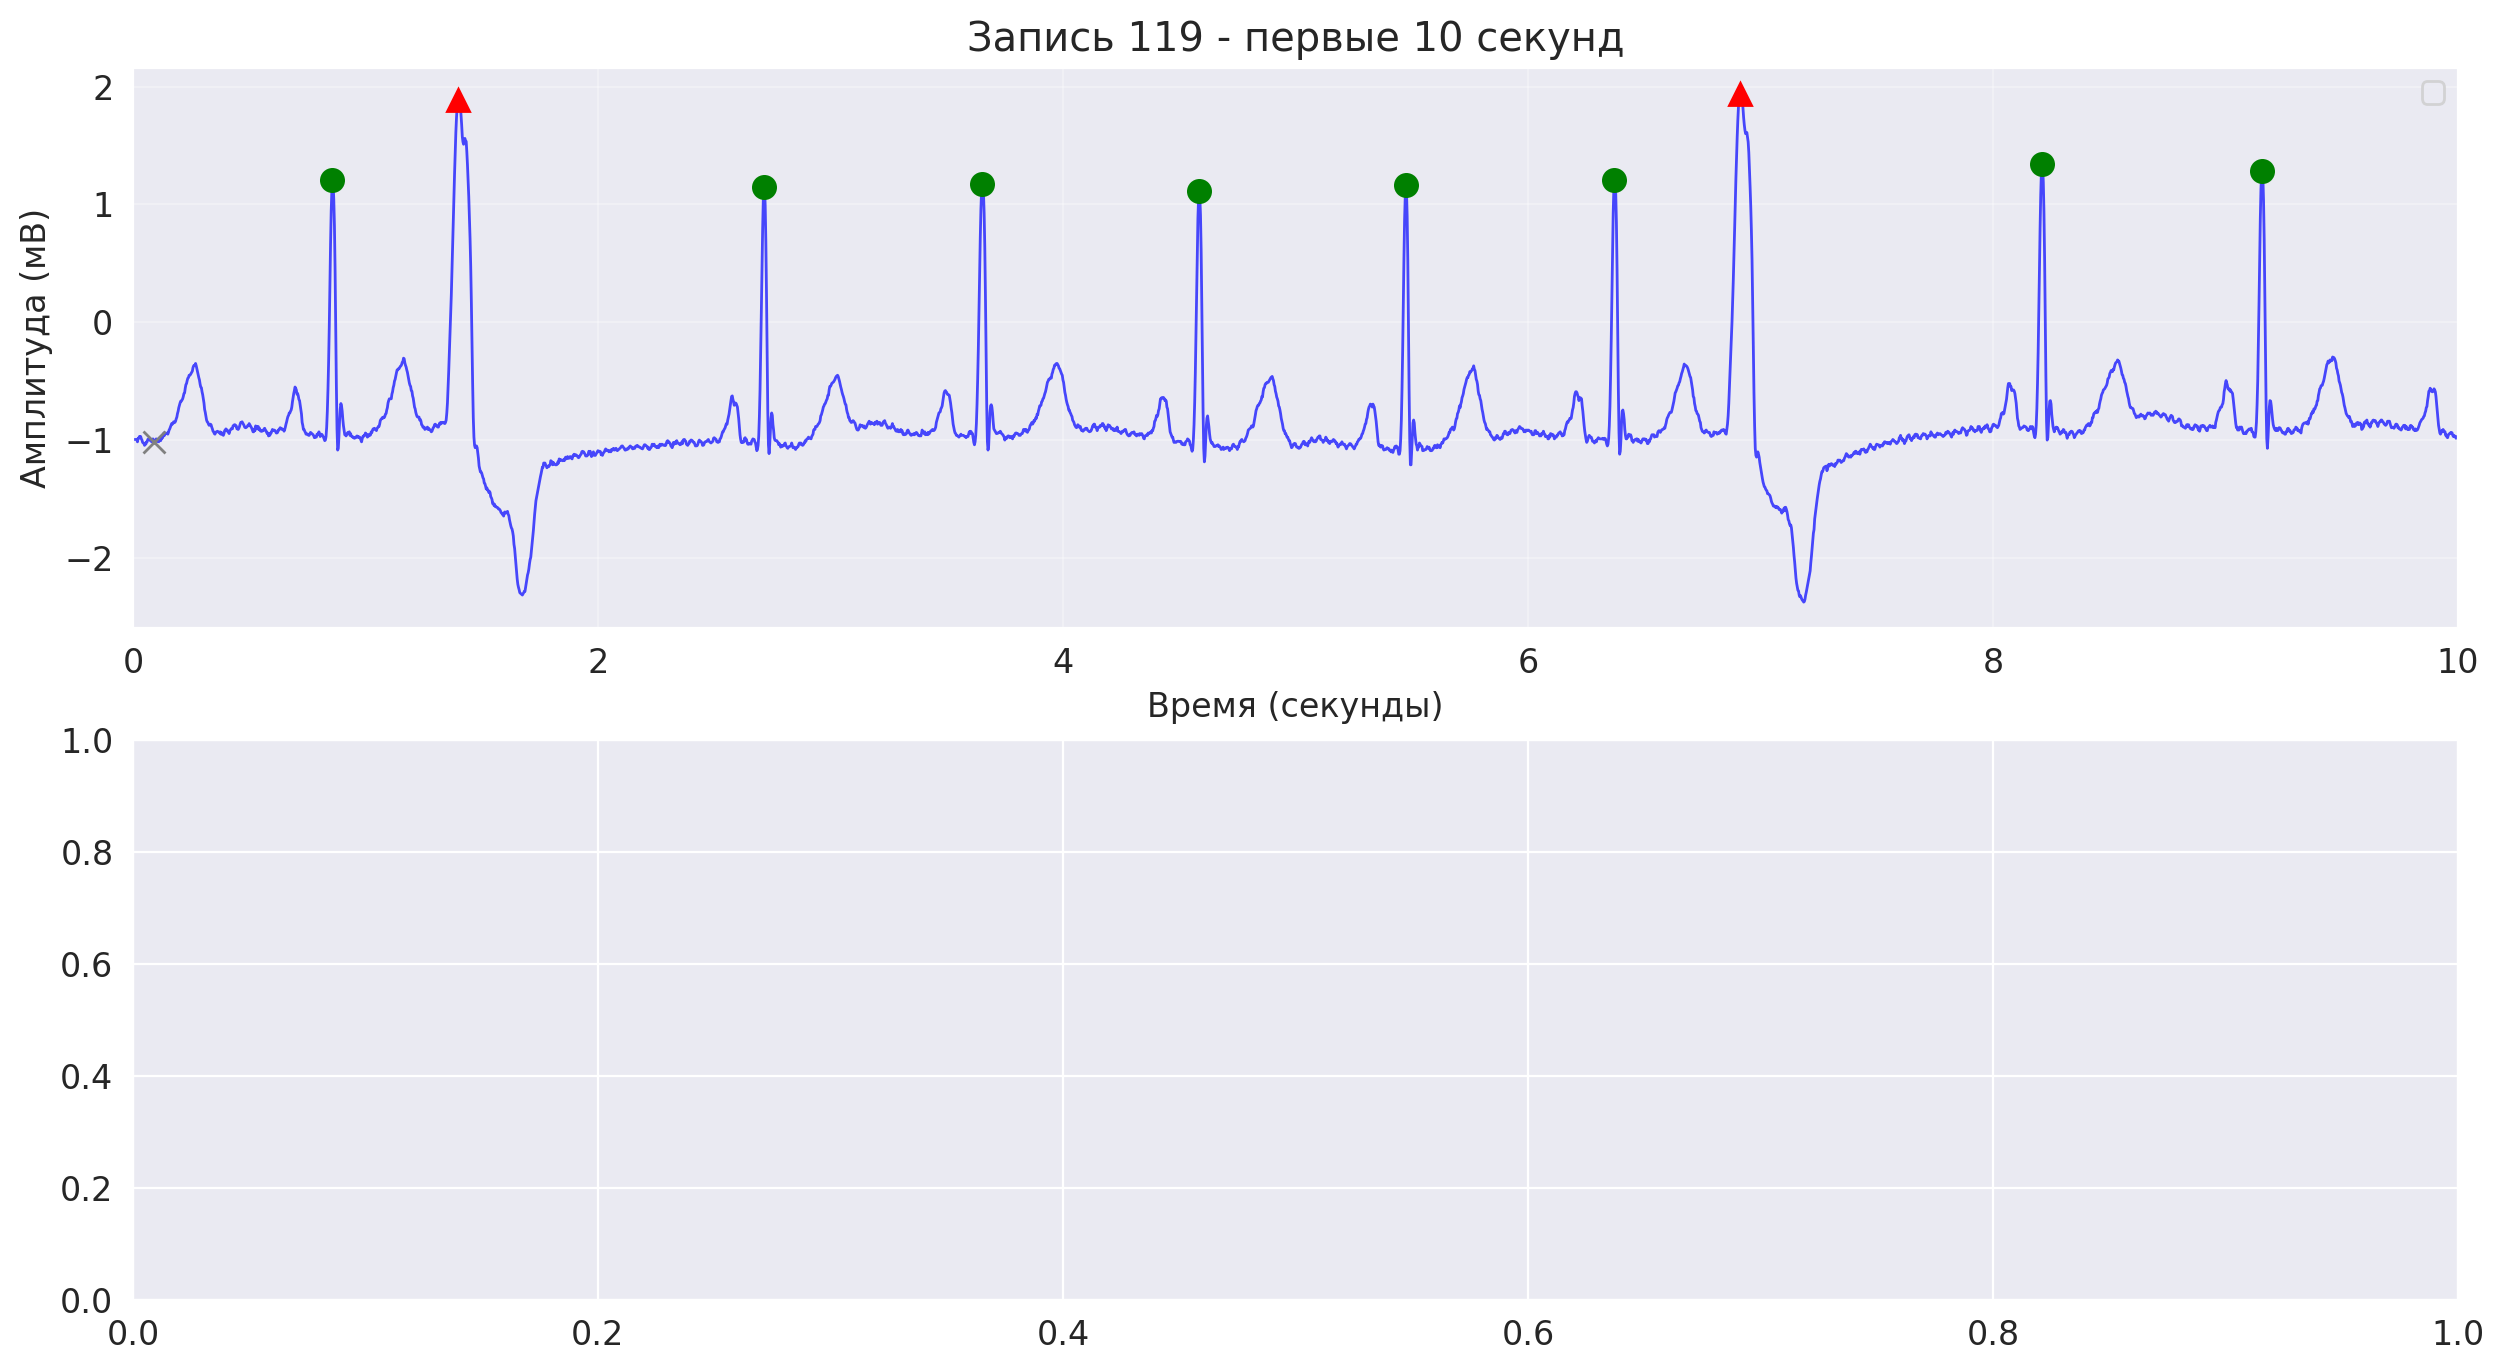

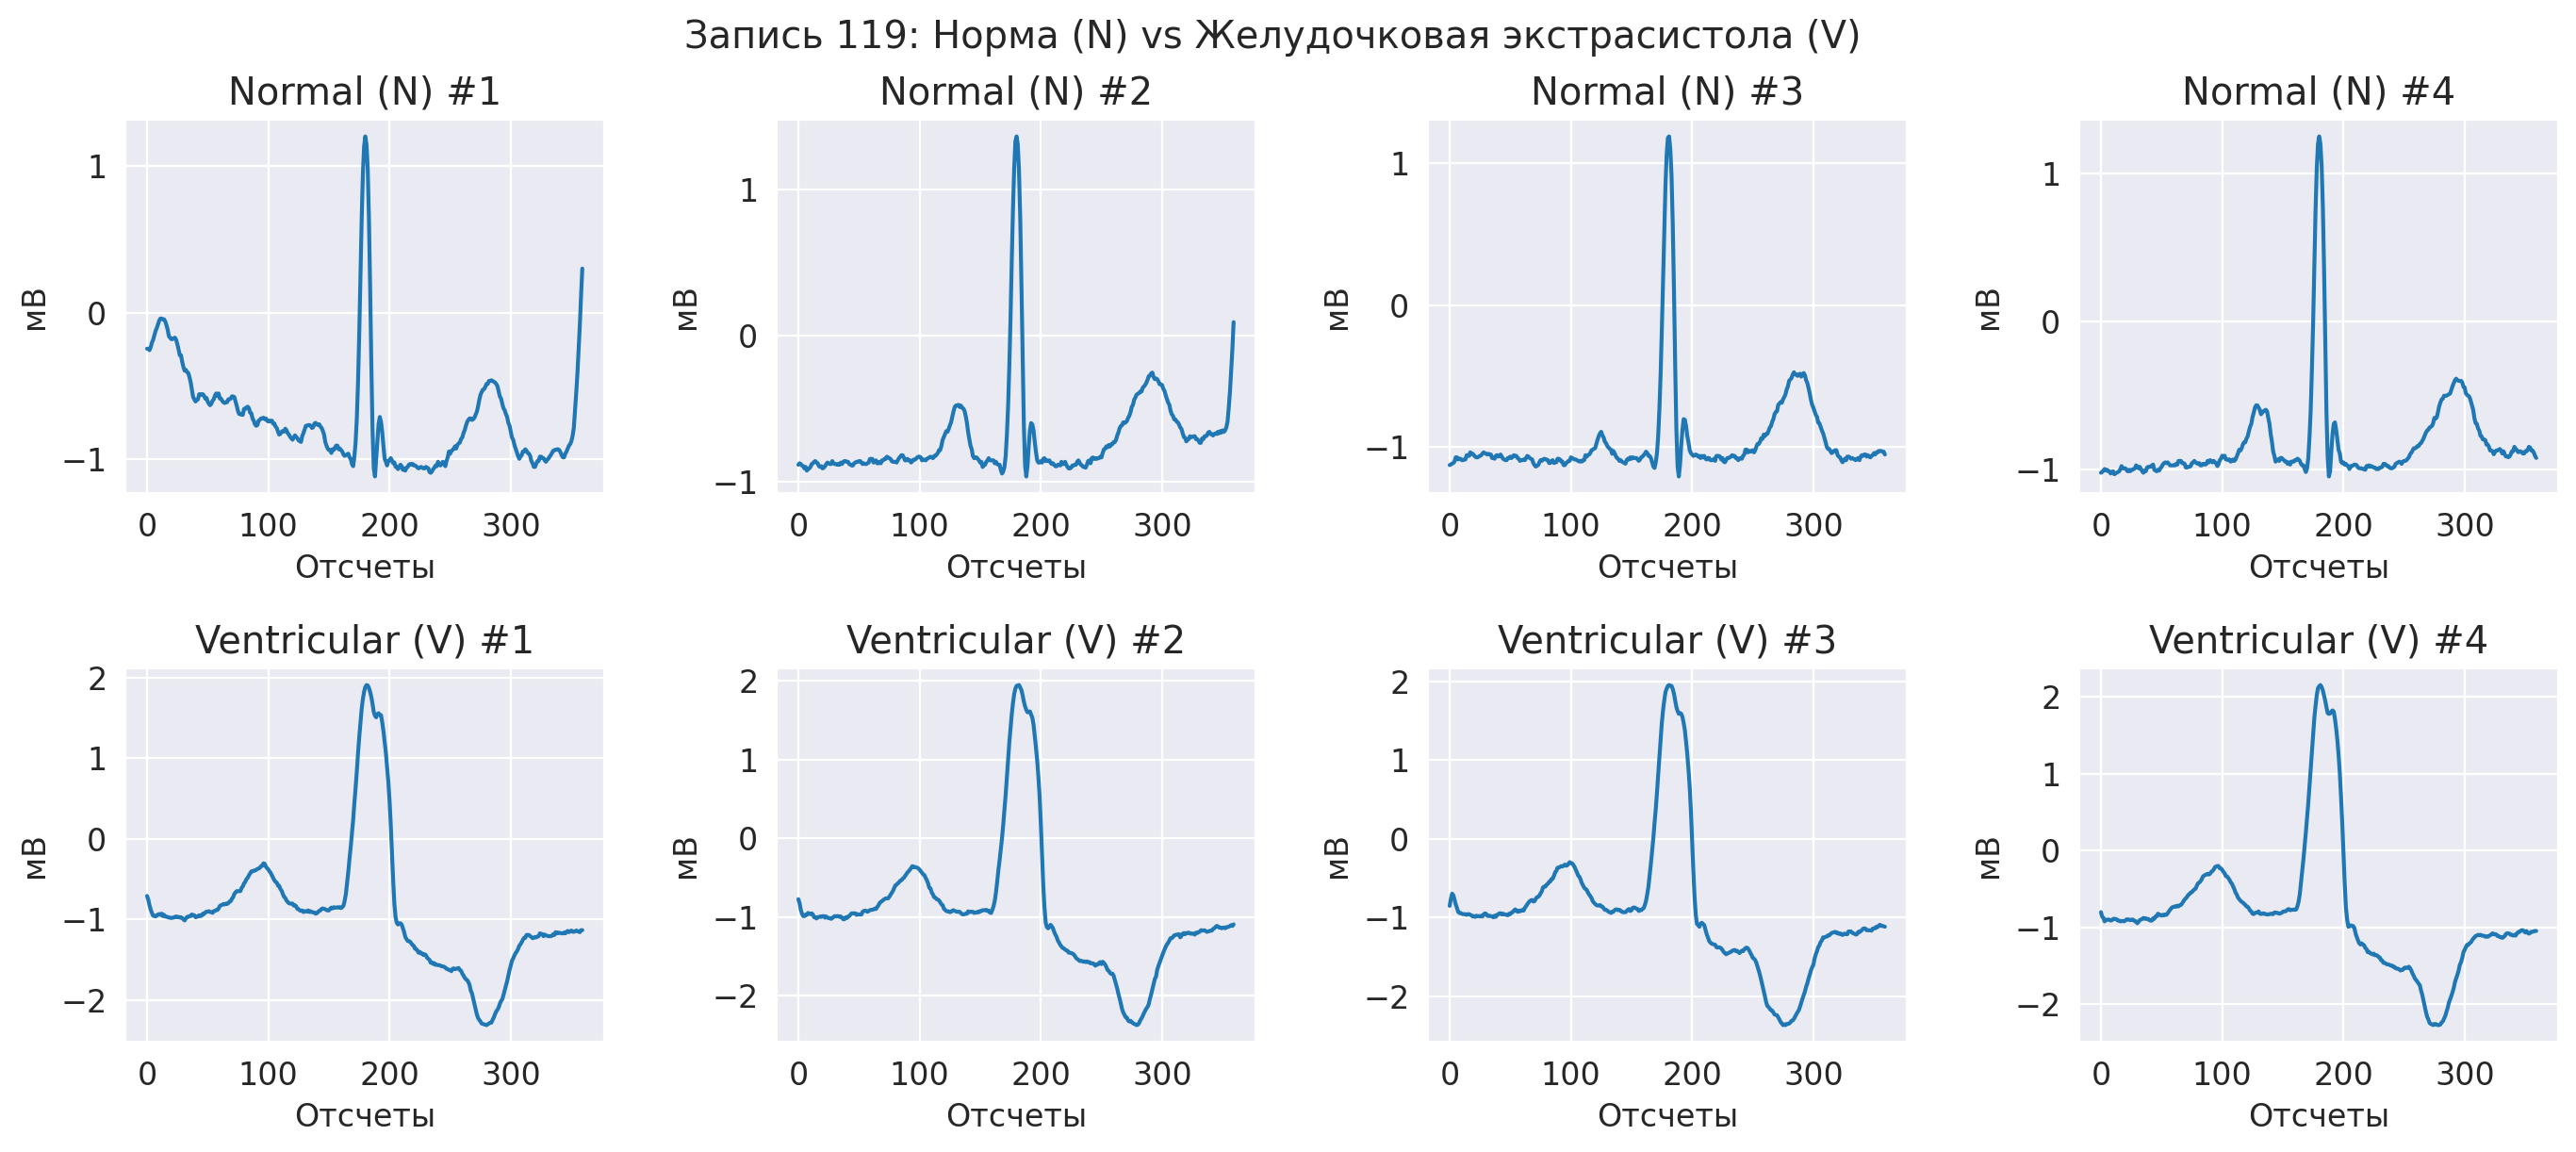

In [ ]:


# ========== ШАГ 2: Загрузить и посмотреть одну запись ==========
record_name = '119'
record = wfdb.rdrecord(f'mitdb_data/{record_name}')
annotation = wfdb.rdann(f'mitdb_data/{record_name}', 'atr')

# Что мы имеем?
print(f"\nЗапись {record_name}:")
print(f"  Частота дискретизации: {record.fs} Гц")
print(f"  Длительность: {record.sig_len / record.fs / 60:.1f} минут")
print(f"  Количество отведений: {record.n_sig}")
print(f"  Названия отведений: {record.sig_name}")
print(f"  Всего размеченных R-зубцов: {len(annotation.sample)}")

# ========== График ==========
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Берем первые 10 секунд (3600 отсчетов при 360 Гц)
seconds_to_show = 10
samples_to_show = seconds_to_show * record.fs
signal = record.p_signal[:samples_to_show, 0]  # первое отведение

# Временная ось в секундах
time = np.arange(len(signal)) / record.fs

# Рисуем сигнал
axes[0].plot(time, signal, 'b-', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Время (секунды)')
axes[0].set_ylabel('Амплитуда (мВ)')
axes[0].set_title(f'Запись {record_name} - первые {seconds_to_show} секунд')
axes[0].grid(True, alpha=0.3)

# Отмечаем размеченные R-зубцы на этом отрезке
for sample, symbol in zip(annotation.sample, annotation.symbol):
    if sample < samples_to_show:
        time_sec = sample / record.fs
        # Разный цвет для разных типов
        if symbol == 'N':
            color = 'green'
            marker = 'o'
            label = 'Normal (N)'
        elif symbol == 'V':
            color = 'red'
            marker = '^'
            label = 'Ventricular (V)'
        elif symbol == 'L':
            color = 'orange'
            marker = 's'
            label = 'LBBB (L)'
        elif symbol == 'R':
            color = 'purple'
            marker = 'd'
            label = 'RBBB (R)'
        else:
            color = 'gray'
            marker = 'x'
            label = f'Other ({symbol})'
        
        # Используем label только для первого элемента каждого типа
        if f"{symbol}_plotted" not in locals():
            axes[0].plot(time_sec, signal[sample], color=color, marker=marker, 
                        markersize=8, label=label, linestyle='None')
            locals()[f"{symbol}_plotted"] = True
        else:
            axes[0].plot(time_sec, signal[sample], color=color, marker=marker, 
                        markersize=8, linestyle='None')

axes[0].legend(loc='upper right', fontsize=10)
axes[0].set_xlim(0, seconds_to_show)

# ========== ШАГ 3: Посмотреть распределение аритмий ==========
# Символы из аннотации (метки каждого R-зубца)
symbols = annotation.symbol

# Частота меток
counts = Counter(symbols)
print(f"\nРаспределение меток в записи {record_name}:")
for sym, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {sym}: {cnt} ({cnt/len(symbols)*100:.1f}%)")

# ========== ШАГ 4: Вырезать ВСЕ желудочковые экстрасистолы (V) ==========
# Нам нужны индексы (номера отсчетов) каждого V-комплекса
v_indices = [annotation.sample[i] for i, sym in enumerate(symbols) if sym == 'V']

# Размер окна вокруг R-зубца (например, 180 отсчетов до и 180 после)
# При 360 Гц это 0.5 секунды до и после (всего 1 секунда ЭКГ)
window_before = 180
window_after = 180

v_segments = []
for idx in v_indices:
    start = max(0, idx - window_before)
    end = min(record.sig_len, idx + window_after)
    
    # Берем первое отведение (обычно MLII) - у него индекс 0
    segment = record.p_signal[start:end, 0]
    
    # Дополняем нулями, если у края (но лучше брать записи подальше от начала)
    if len(segment) < window_before + window_after:
        segment = np.pad(segment, 
                        (0, window_before + window_after - len(segment)),
                        constant_values=0)
    v_segments.append(segment)

print(f"\nВырезано {len(v_segments)} желудочковых экстрасистол")
print(f"Размер каждого сегмента: {len(v_segments[0])} отсчетов")

# ========== ШАГ 5: Для сравнения — вырезать нормальные комплексы (N) ==========
n_indices = [annotation.sample[i] for i, sym in enumerate(symbols) if sym == 'N']

# Возьмем столько же N, сколько V (для баланса)
import random
random.seed(42)
n_indices_sampled = random.sample(n_indices, min(len(n_indices), len(v_indices)))

n_segments = []
for idx in n_indices_sampled:
    start = max(0, idx - window_before)
    end = min(record.sig_len, idx + window_after)
    segment = record.p_signal[start:end, 0]
    if len(segment) < window_before + window_after:
        segment = np.pad(segment,
                        (0, window_before + window_after - len(segment)),
                        constant_values=0)
    n_segments.append(segment)

print(f"Вырезано {len(n_segments)} нормальных комплексов")

# ========== ШАГ 6: Визуализация отличий ==========
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

# Нормальные (первые 4)
for i in range(4):
    axes[0, i].plot(n_segments[i])
    axes[0, i].set_title(f'Normal (N) #{i+1}')
    axes[0, i].set_xlabel('Отсчеты')
    axes[0, i].set_ylabel('мВ')

# Желудочковые (первые 4)
for i in range(4):
    axes[1, i].plot(v_segments[i])
    axes[1, i].set_title(f'Ventricular (V) #{i+1}')
    axes[1, i].set_xlabel('Отсчеты')
    axes[1, i].set_ylabel('мВ')

plt.tight_layout()
plt.suptitle(f'Запись {record_name}: Норма (N) vs Желудочковая экстрасистола (V)', y=1.02)
plt.show()




#### Извлекаем из медицинский временных рядов отрезки с ударами

In [27]:
def extract_heartbeats_preserving_amplitude(record_names, window_before=120, window_after=180, n_segments = 100):
    """
    Извлекает сегменты БЕЗ нормализации внутри сегмента
    """
    all_segments = []
    all_labels = []
    all_sources = []
    all_amplitudes = []  # сохраним амплитуду для анализа
    
    window_size = window_before + window_after
    
    for rec_name in record_names:
        record = wfdb.rdrecord(f'mitdb_data/{rec_name}')
        annotation = wfdb.rdann(f'mitdb_data/{rec_name}', 'atr')
        
        # Глобальная нормализация для всей записи (один раз!)
        signal = record.p_signal[:, 0]
        
        # Центрируем (убираем постоянное смещение), НО сохраняем амплитуду
        # Используем медиану всей записи
        global_median = np.median(signal)
        signal_centered = signal - global_median
        
        # Опционально: делим на MAD всей записи (но это уже нормализация)
        # global_mad = np.median(np.abs(signal_centered))
        # signal_normalized = signal_centered / (global_mad + 1e-8)
        
        # Для кластеризации лучше использовать центрированный сигнал без деления
        
        skip_labels = {'?', 'Q', '+', '~'}
        cnt = 0
        for sample, symbol in zip(annotation.sample, annotation.symbol):
            if symbol in skip_labels:
                continue
            cnt += 1
            if cnt > n_segments:
                break
            start = max(0, sample - window_before)
            end = min(len(signal_centered), sample + window_after)
            
            if end - start == window_size:
                segment = signal_centered[start:end]
                
                # Сохраняем амплитуду как дополнительный признак
                amplitude = np.max(np.abs(segment))
                
                all_segments.append(segment)
                all_labels.append(symbol)
                all_sources.append(rec_name)
                all_amplitudes.append(amplitude)
    
    return np.array(all_segments), all_labels, all_sources, all_amplitudes

In [28]:
records = ['100', '101', '119', '208', '221']
WINDOW_BEFORE = 120
WINDOW_AFTER = 180

segments, labels, sources, amplitudes = extract_heartbeats_preserving_amplitude(records)

# Преобразуем в формат для tslearn (n_samples, timesteps, n_features)
X = segments.reshape(segments.shape[0], segments.shape[1], 1)
print(X.shape)
model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=42)
clusters = model.fit_predict(X)

(497, 300, 1)


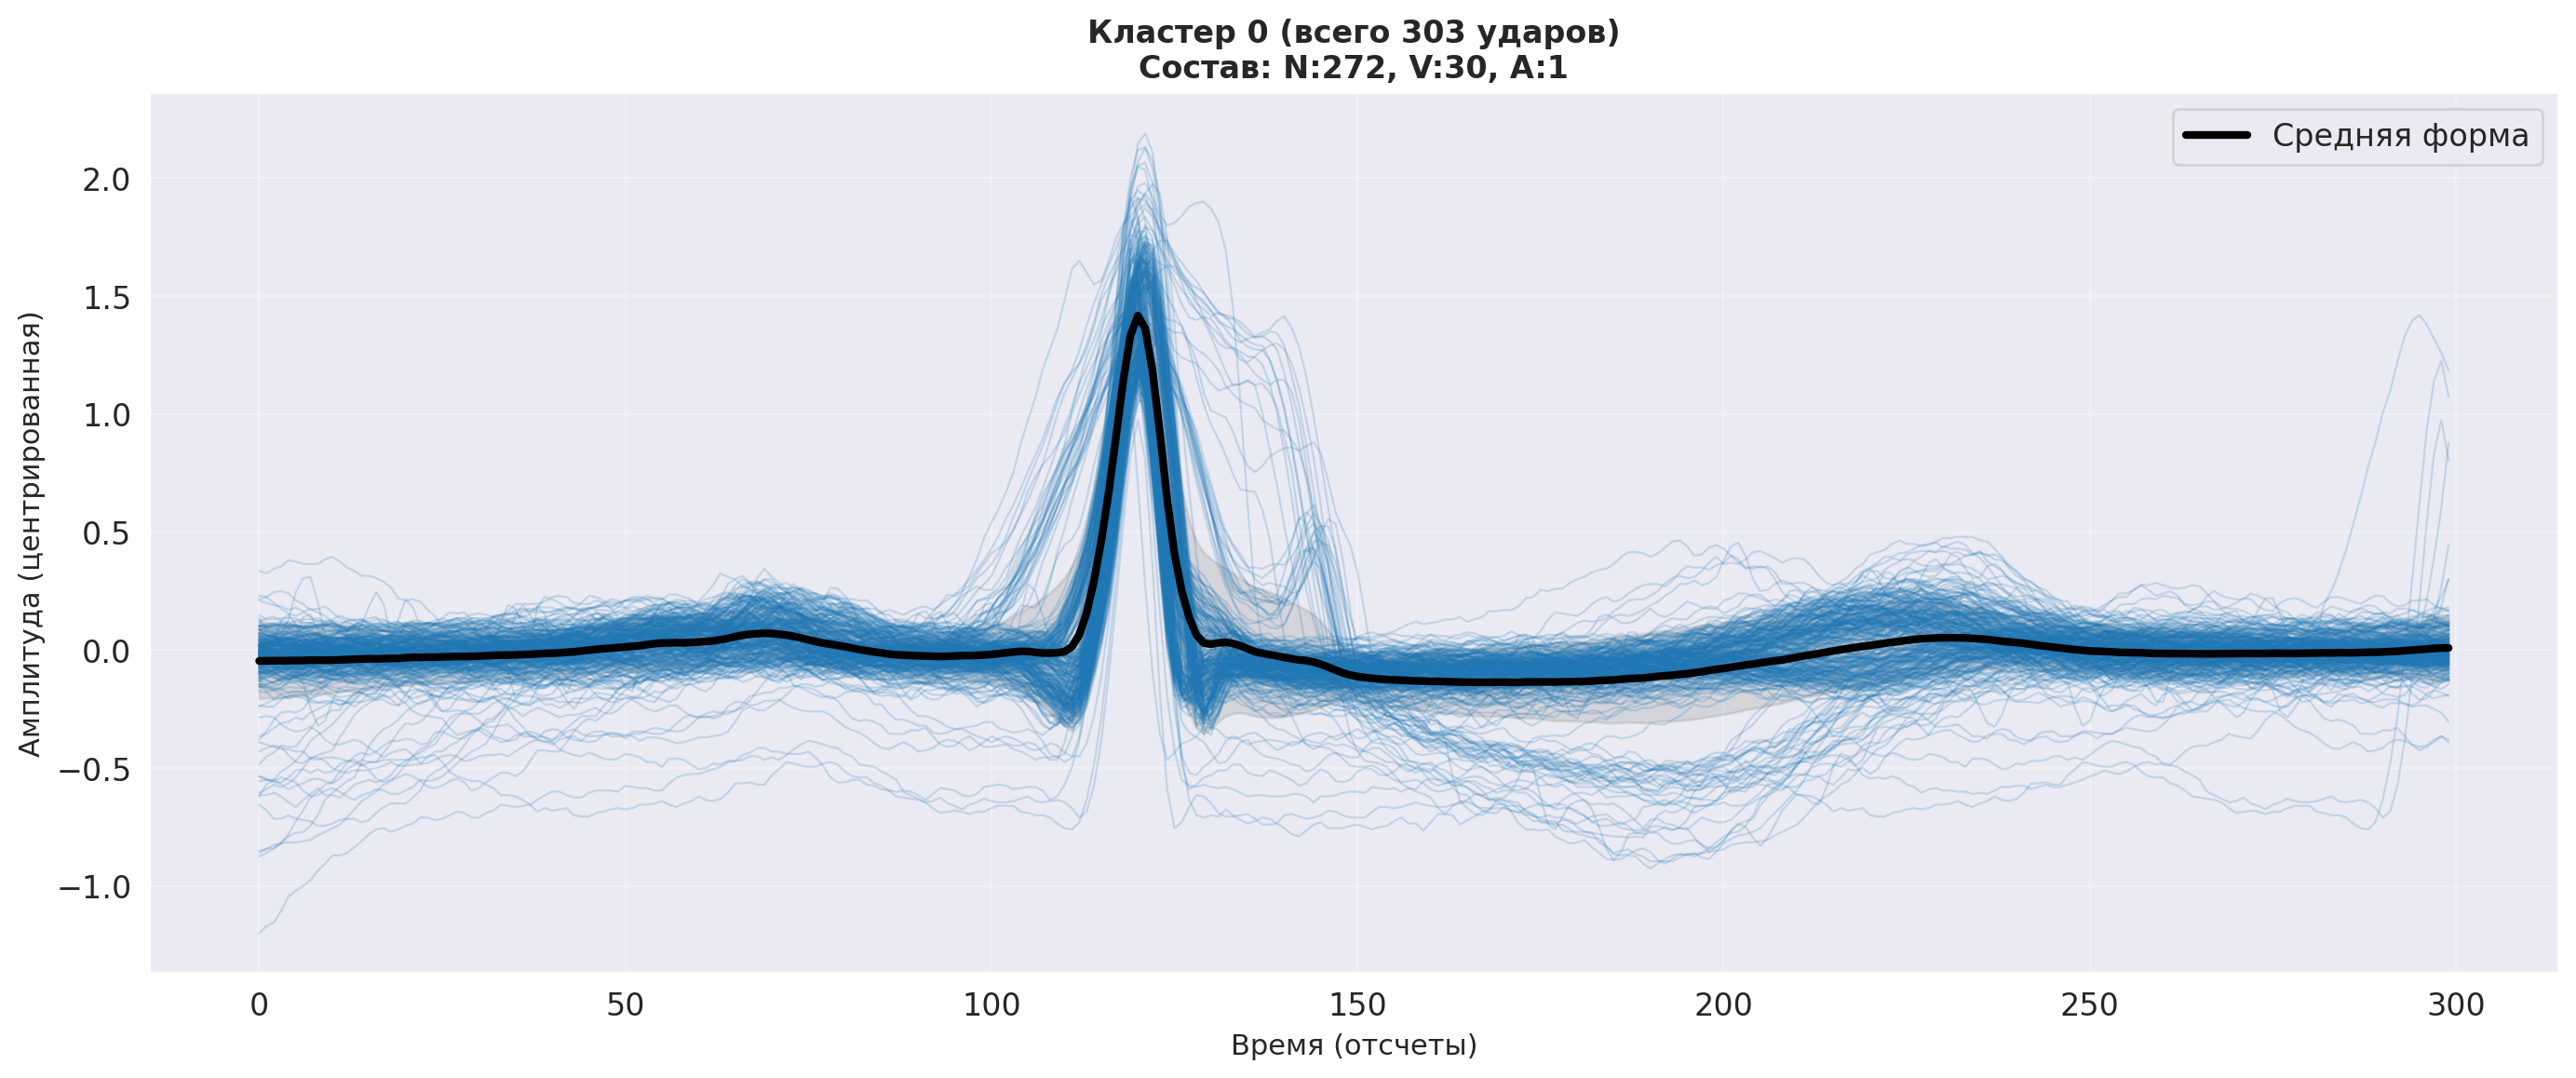

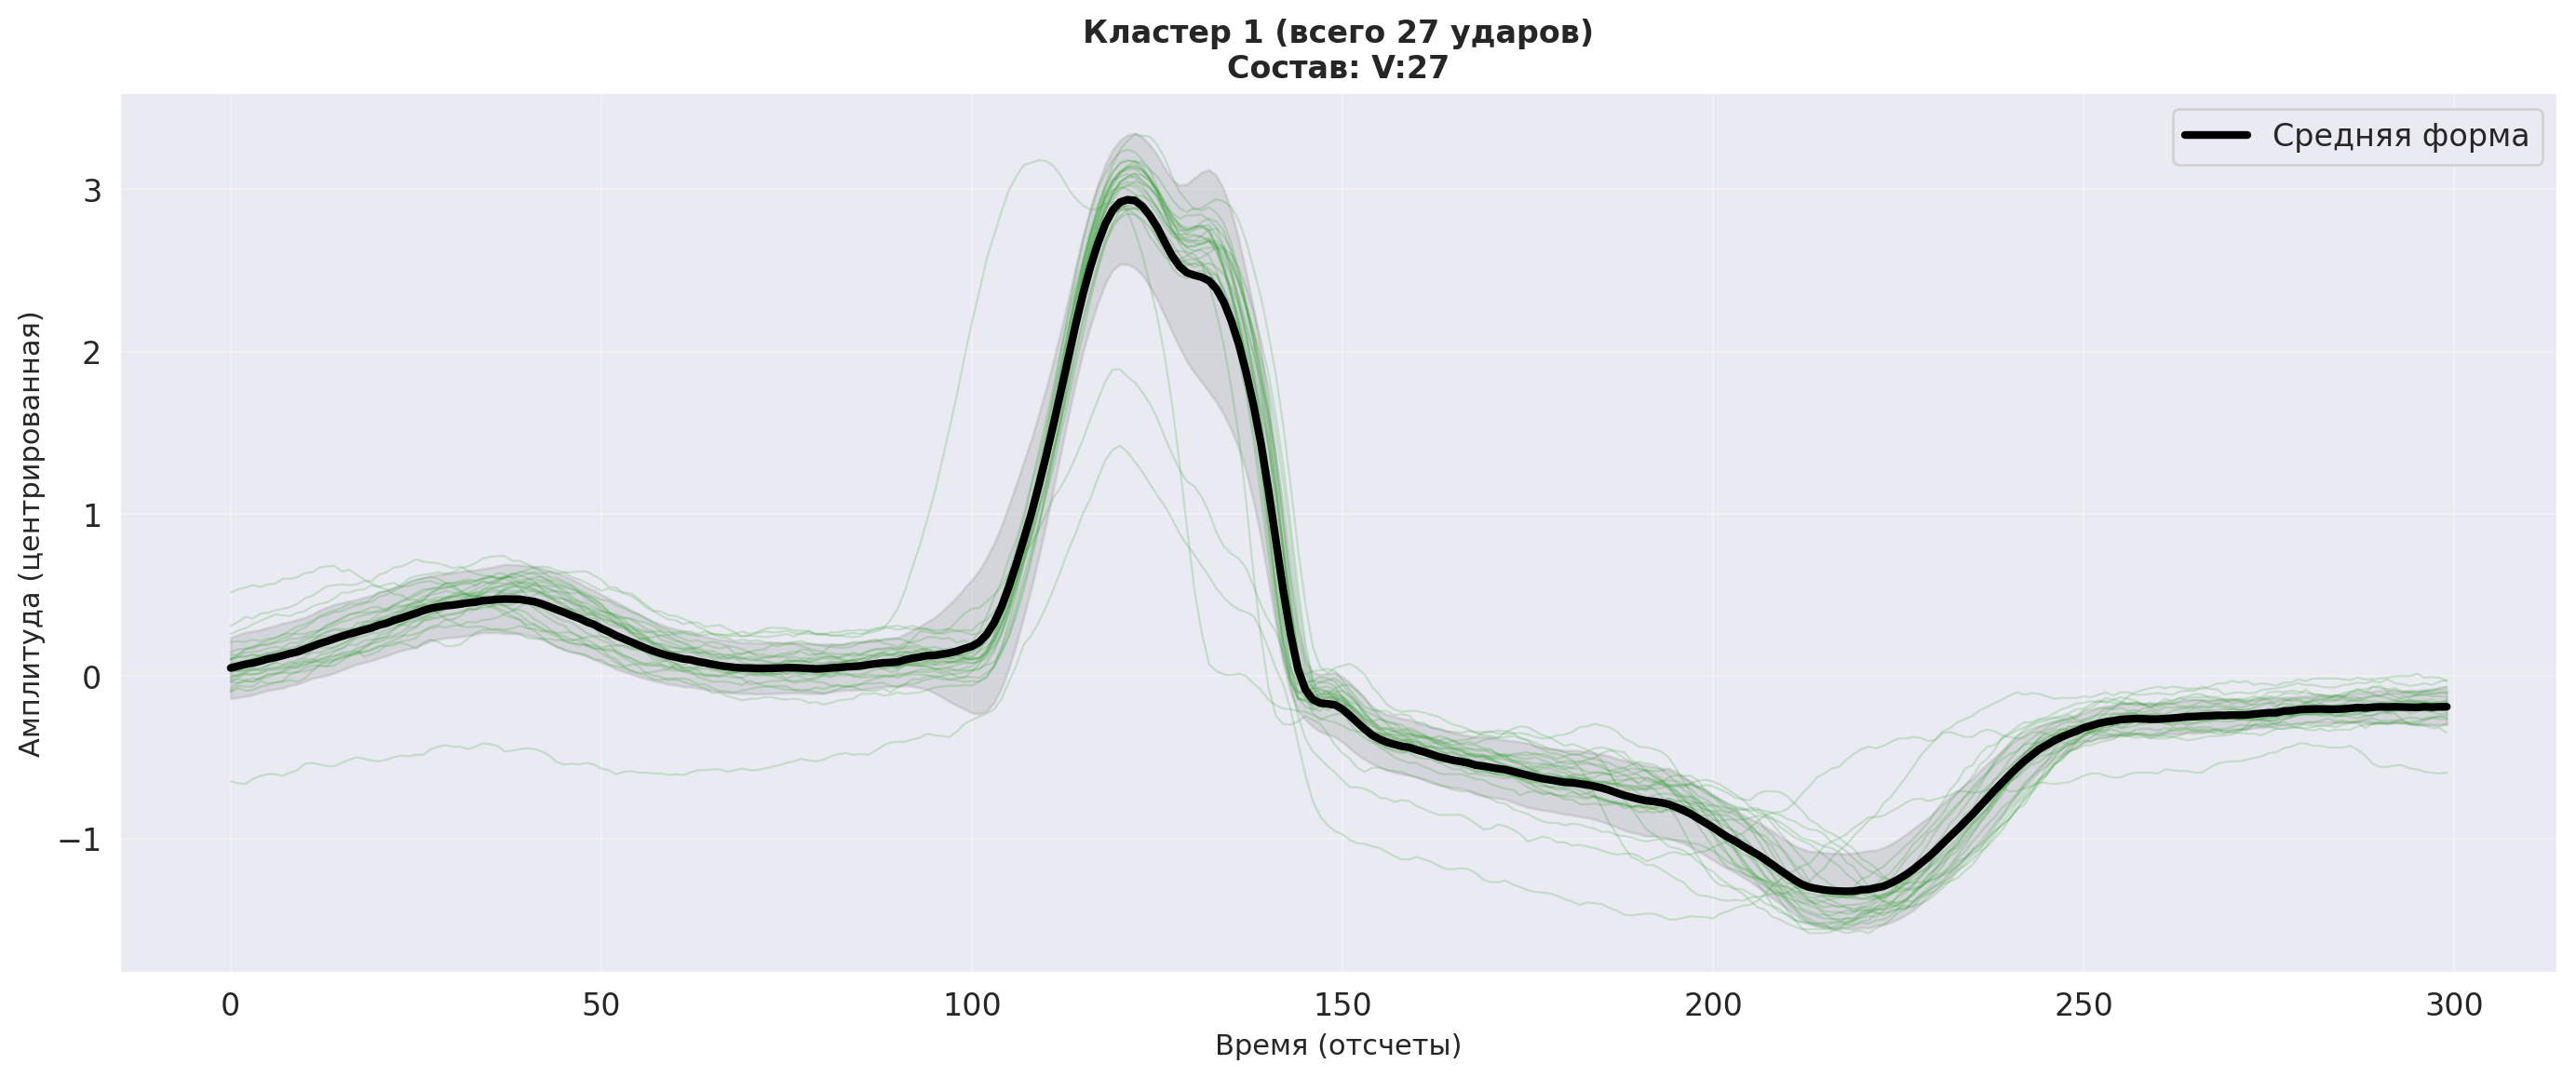

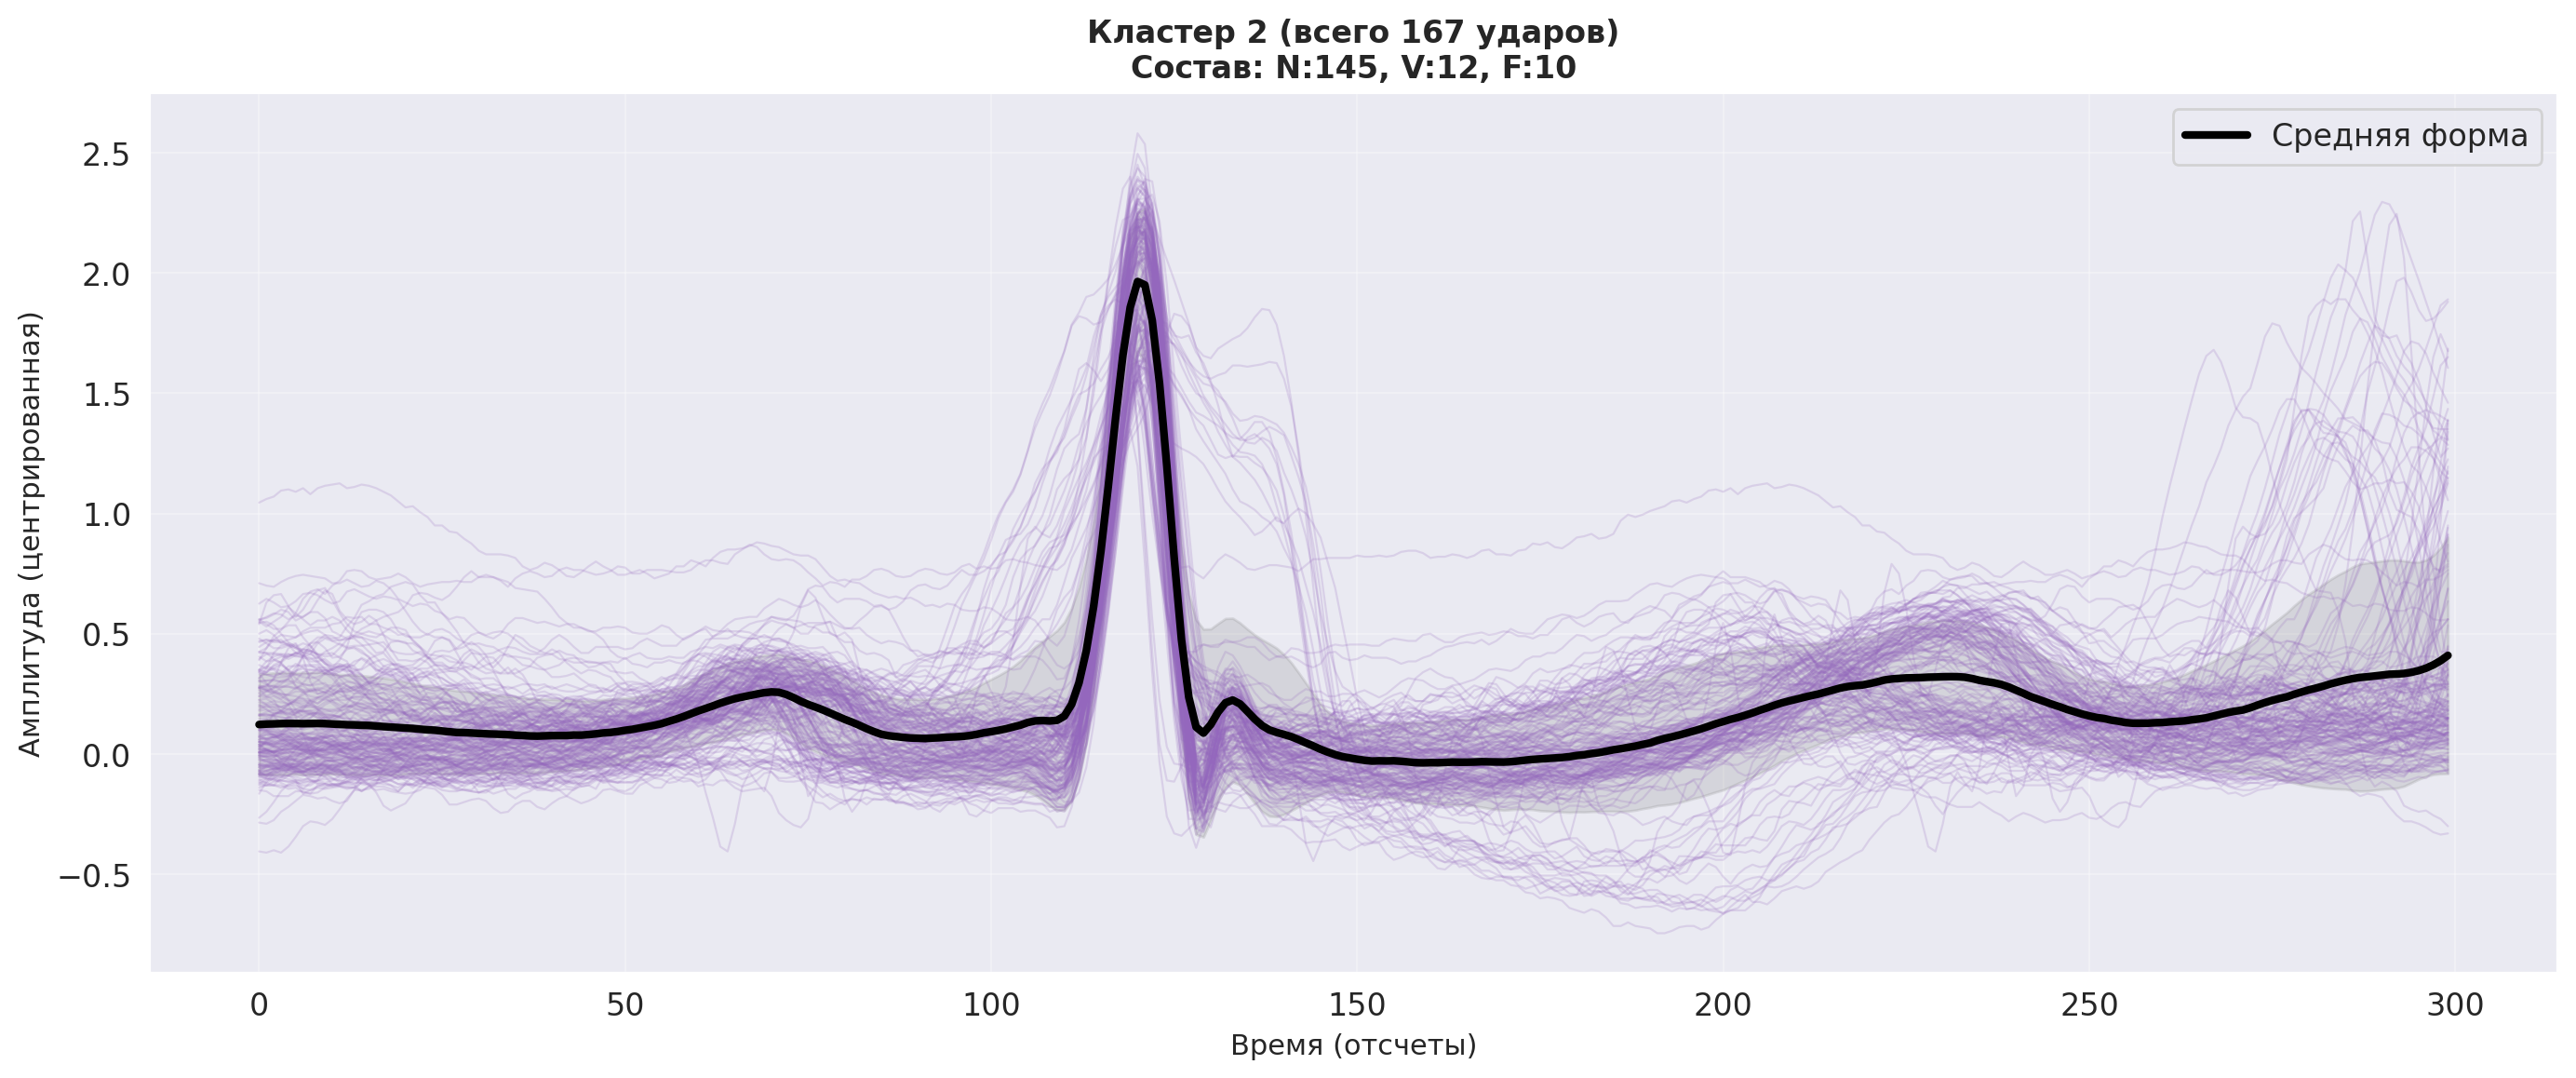

In [29]:
def plot_clusters_simple(X, clusters, true_labels, n_clusters):
    """
    Простая и красивая версия — один кластер = одно окно
    """
    from collections import Counter
    
    # Красивая цветовая палитра для разных типов
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    for cluster_id in range(n_clusters):
        indices = np.where(clusters == cluster_id)[0]
        
        if len(indices) == 0:
            continue
        
        # Анализ состава
        label_counts = Counter([true_labels[i] for i in indices])
        
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Рисуем все ряды с полупрозрачными линиями
        for idx in indices:
            ax.plot(X[idx, :, 0], alpha=0.2, linewidth=0.8, 
                   color=colors[cluster_id % len(colors)])
        
        # Рисуем среднюю линию жирно
        mean_series = X[indices].mean(axis=0)
        ax.plot(mean_series[:, 0], 'k-', linewidth=3, label='Средняя форма')
        
        # Добавляем доверительный интервал
        if len(indices) > 1:
            std_series = X[indices].std(axis=0)
            ax.fill_between(range(len(mean_series)), 
                            mean_series[:, 0] - std_series[:, 0],
                            mean_series[:, 0] + std_series[:, 0],
                            alpha=0.2, color='gray')
        
        # Формируем заголовок с информацией о составе
        top_labels = ', '.join([f"{l}:{c}" for l, c in label_counts.most_common(3)])
        ax.set_title(f'Кластер {cluster_id} (всего {len(indices)} ударов)\nСостав: {top_labels}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Время (отсчеты)', fontsize=11)
        ax.set_ylabel('Амплитуда (центрированная)', fontsize=11)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

plot_clusters_simple(X, clusters, labels, n_clusters=6)